<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Lesson_7_assignment-AK/blob/main/Lesson_7_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Imports librairies

In [1]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Step 2: Data Collection and Loading

In [2]:
# --- Data Collection and Loading ---
# TODO: Load the 'Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Alternative fix for modern sklearn: fetch from OpenML to avoid removal errors.

boston = fetch_openml(name="boston", version=1, as_frame=True, parser="auto")
df = boston.frame

# Ensure proper naming for the target variable column
if 'MEDV' not in df.columns and 'target' in df.columns:
    df.rename(columns={'target': 'MEDV'}, inplace=True)
elif 'MEDV' not in df.columns:
    df['MEDV'] = boston.target

Step 3: Quick Check of Data

In [3]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


Step 4: EDA and Data Preprocessing

In [5]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


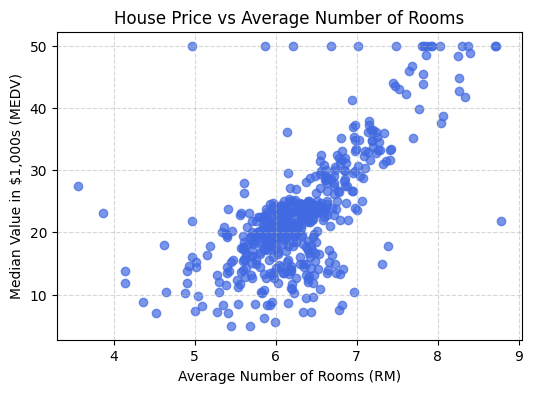

In [6]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
plt.figure(figsize=(6, 4))
plt.scatter(df['RM'], df['MEDV'], color='royalblue', alpha=0.7)
plt.title('House Price vs Average Number of Rooms')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median Value in $1,000s (MEDV)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
# TODO: Create a function to automate scatter plots for all features vs the target variable.
def plot_features_vs_target(features, target_column, dataframe):
    num_plots = len(features)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 4))

    # Handle single feature edge case
    if num_plots == 1:
        axes = [axes]

    for i, col in enumerate(features):
        axes[i].scatter(dataframe[col], dataframe[target_column], alpha=0.6, color='teal')
        axes[i].set_title(f'{col} vs {target_column}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_column)
        axes[i].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

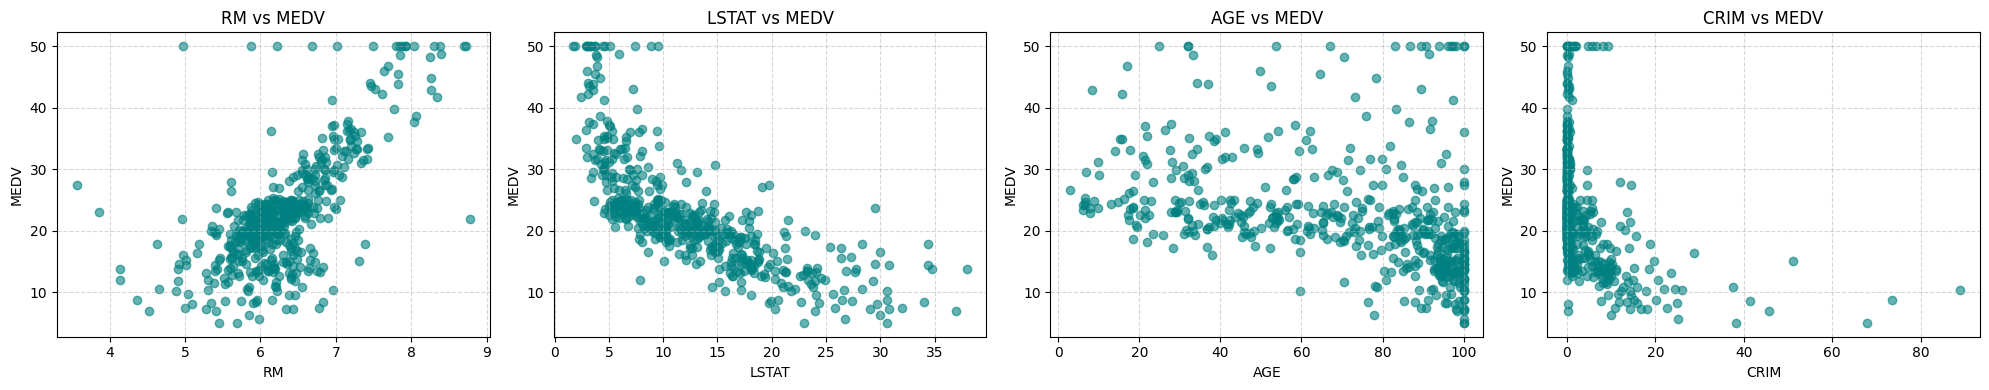

In [8]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
selected_features = ['RM', 'LSTAT', 'AGE', 'CRIM']
plot_features_vs_target(selected_features, 'MEDV', df)

Step 5: ML Model Training

In [9]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.

# Convert categorical columns (like CHAS or RAD) to numeric code formats if they are categorized as categories
for col in df.columns:
    if df[col].dtype.name == 'category':
        df[col] = df[col].cat.codes

X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Selecting Random Forest Regressor for better generalization and robust handling
model = RandomForestRegressor(random_state=42)

In [11]:
# TODO: Train the model on the training data.
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Step 6: Model Evaluation & Hyperparameter Tuning

In [12]:
# --- Model Evaluation ---
# Perform parameter tuning on the model if needed to improve the performance of your model.

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Use the best optimized model configuration
best_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")

Best Parameters Found: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}


In [13]:
# Predict on the test set and calculate the evaluation metrics:
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): ${rmse * 1000:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Root Mean Squared Error (RMSE): $2727.43
R-squared (R2 Score): 0.8986


Step 7: Model Prediction on New Input

In [14]:
# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.

new_data = pd.DataFrame([{
    'CRIM': 0.2,
    'ZN': 12.5,
    'INDUS': 7.07,
    'CHAS': 0,
    'NOX': 0.5,
    'RM': 6.5,
    'AGE': 68,
    'DIS': 4.0,
    'RAD': 2,
    'TAX': 250,
    'PTRATIO': 17,
    'B': 400,
    'LSTAT': 12
}])

# Align categorical formats with data training configurations if needed
for col in X.columns:
    if X[col].dtype.name == 'int8' or X[col].dtype.name == 'int64':
        new_data[col] = new_data[col].astype(X[col].dtype)

predicted_price = best_model.predict(new_data)
print(f"Predicted Median House Price: ${predicted_price[0] * 1000:.2f}")

Predicted Median House Price: $22380.00
